In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nafiulislam490/bank-transaction-fraud-detection-dataset/bank_fraud.csv


In [2]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/nafiulislam490/bank-transaction-fraud-detection-dataset/bank_fraud.csv")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
df.head()

Rows: 1,000,000 | Columns: 26


,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0,NaN


In [4]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   transaction_date          1000000 non-null  object 
 3   transaction_time          1000000 non-null  object 
 4   hour_of_day               1000000 non-null  int64  
 5   is_weekend                1000000 non-null  int64  
 6   is_night_transaction      1000000 non-null  int64  
 7   country                   1000000 non-null  object 
 8   city                      1000000 non-null  object 
 9   merchant_category         1000000 non-null  object 
 10  payment_method            1000000 non-null  object 
 11  device_type               1000000 non-null  object 
 12  customer_age              1000000 non-null  int64  
 13  credit_score              10

In [5]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: x["missing_count"] / len(df))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

duplicate_rows = df.duplicated().sum()
duplicate_transactions = df["transaction_id"].duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Duplicate transaction IDs: {duplicate_transactions:,}")
missing_summary

Duplicate rows: 0
Duplicate transaction IDs: 0


,missing_count,missing_pct
fraud_type,944745,0.944745


is_fraud
0    944745
1     55255
Name: count, dtype: int64
Fraud rate: 5.53%


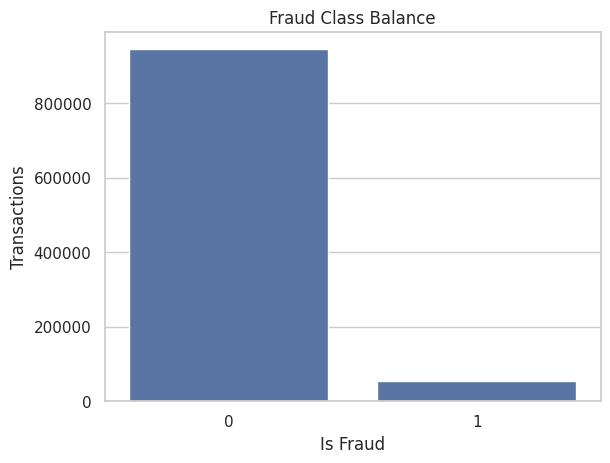

In [6]:
target_counts = df["is_fraud"].value_counts().sort_index()
target_rate = df["is_fraud"].mean()

print(target_counts)
print(f"Fraud rate: {target_rate:.2%}")

ax = sns.countplot(data=df, x="is_fraud")
ax.set_title("Fraud Class Balance")
ax.set_xlabel("Is Fraud")
ax.set_ylabel("Transactions")
plt.show()

In [7]:
def clean_and_engineer_features(raw_df: pd.DataFrame) -> pd.DataFrame:
    data = raw_df.copy()

    data = data.drop_duplicates().reset_index(drop=True)

    data["transaction_datetime"] = pd.to_datetime(
        data["transaction_date"].astype(str) + " " + data["transaction_time"].astype(str),
        errors="coerce",
    )
    data["transaction_year"] = data["transaction_datetime"].dt.year
    data["transaction_month"] = data["transaction_datetime"].dt.month
    data["transaction_day"] = data["transaction_datetime"].dt.day
    data["transaction_dayofweek"] = data["transaction_datetime"].dt.dayofweek
    data["transaction_quarter"] = data["transaction_datetime"].dt.quarter

    data["amount_log1p"] = np.log1p(data["transaction_amount"].clip(lower=0))
    data["balance_log1p"] = np.log1p(data["account_balance"].clip(lower=0))
    data["amount_to_balance_ratio"] = data["transaction_amount"] / data["account_balance"].replace(0, np.nan)
    data["amount_to_balance_ratio"] = data["amount_to_balance_ratio"].replace([np.inf, -np.inf], np.nan)
    data["amount_to_balance_ratio"] = data["amount_to_balance_ratio"].fillna(0).clip(upper=10)

    data["transactions_per_account_year"] = data["num_prev_transactions"] / data["account_age_years"].replace(0, np.nan)
    data["transactions_per_account_year"] = data["transactions_per_account_year"].replace([np.inf, -np.inf], np.nan).fillna(0)
    data["failed_attempt_rate"] = data["failed_attempts"] / (data["num_prev_transactions"] + 1)
    data["is_large_transaction"] = (data["transaction_amount"] > data["transaction_amount"].quantile(0.95)).astype(int)
    data["is_far_from_home"] = (data["distance_from_home_km"] > data["distance_from_home_km"].quantile(0.95)).astype(int)
    data["is_rapid_repeat_txn"] = (data["time_since_last_txn_hrs"] <= 1).astype(int)

    return data


df_clean = clean_and_engineer_features(df)
print(df_clean.shape)
df_clean.head()

(1000000, 40)


,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,transaction_datetime,transaction_year,transaction_month,transaction_day,transaction_dayofweek,transaction_quarter,amount_log1p,balance_log1p,amount_to_balance_ratio,transactions_per_account_year,failed_attempt_rate,is_large_transaction,is_far_from_home,is_rapid_repeat_txn
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0,NaN,2023-08-17 21:13:00,2023,8,17,3,3,3.701055,5.914476,0.106915,21.805556,0.000000,0,0,0
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0,NaN,2024-02-06 05:16:00,2024,2,6,1,1,5.041552,7.894687,0.057312,17.790698,0.000000,0,0,0
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0,NaN,2024-06-28 12:15:00,2024,6,28,4,2,4.780803,10.705302,0.002651,14.907407,0.006173,0,0,1
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity,2023-03-16 02:53:00,2023,3,16,3,1,3.921973,7.101981,0.040795,21.917808,0.000000,0,0,0
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0,NaN,2024-07-12 12:39:00,2024,7,12,4,3,3.457578,10.452072,0.000888,11.355932,0.000000,0,0,0


In [8]:
numeric_summary = df_clean.describe().T
numeric_summary

,count,mean,min,25%,50%,75%,max,std
hour_of_day,1000000.0,11.496978,0.0,5.0,11.0,18.0,23.0,6.923751
is_weekend,1000000.0,0.286022,0.0,0.0,0.0,1.0,1.0,0.4519
is_night_transaction,1000000.0,0.375057,0.0,0.0,0.0,1.0,1.0,0.484138
customer_age,1000000.0,41.771678,18.0,32.0,42.0,51.0,85.0,13.424588
credit_score,1000000.0,679.028781,300.0,625.0,680.0,734.0,850.0,78.828748
account_age_years,1000000.0,4.987911,0.1,1.4,3.5,6.9,30.0,4.925949
account_balance,1000000.0,16594.25442,100.0,3609.0175,8092.12,18225.025,500000.0,28171.46068
transaction_amount,1000000.0,204.724665,1.0,33.4,73.12,181.45,46129.6,459.567802
num_prev_transactions,1000000.0,149.99635,96.0,142.0,150.0,158.0,213.0,12.244379
transaction_freq_monthly,1000000.0,19.999322,2.0,17.0,20.0,23.0,44.0,4.474045


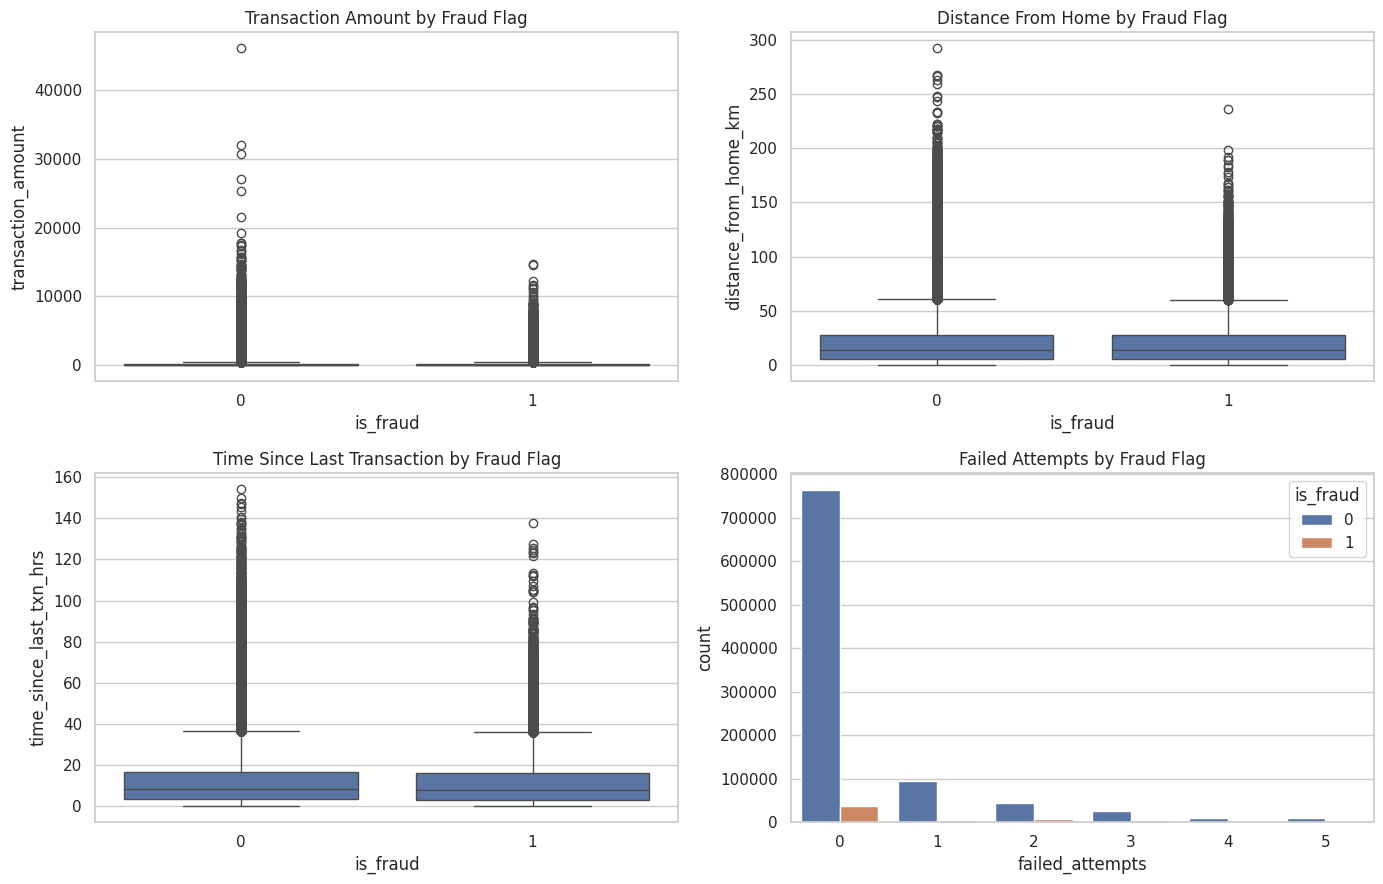

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(data=df_clean, x="is_fraud", y="transaction_amount", ax=axes[0, 0])
axes[0, 0].set_title("Transaction Amount by Fraud Flag")

sns.boxplot(data=df_clean, x="is_fraud", y="distance_from_home_km", ax=axes[0, 1])
axes[0, 1].set_title("Distance From Home by Fraud Flag")

sns.boxplot(data=df_clean, x="is_fraud", y="time_since_last_txn_hrs", ax=axes[1, 0])
axes[1, 0].set_title("Time Since Last Transaction by Fraud Flag")

sns.countplot(data=df_clean, x="failed_attempts", hue="is_fraud", ax=axes[1, 1])
axes[1, 1].set_title("Failed Attempts by Fraud Flag")

plt.tight_layout()
plt.show()

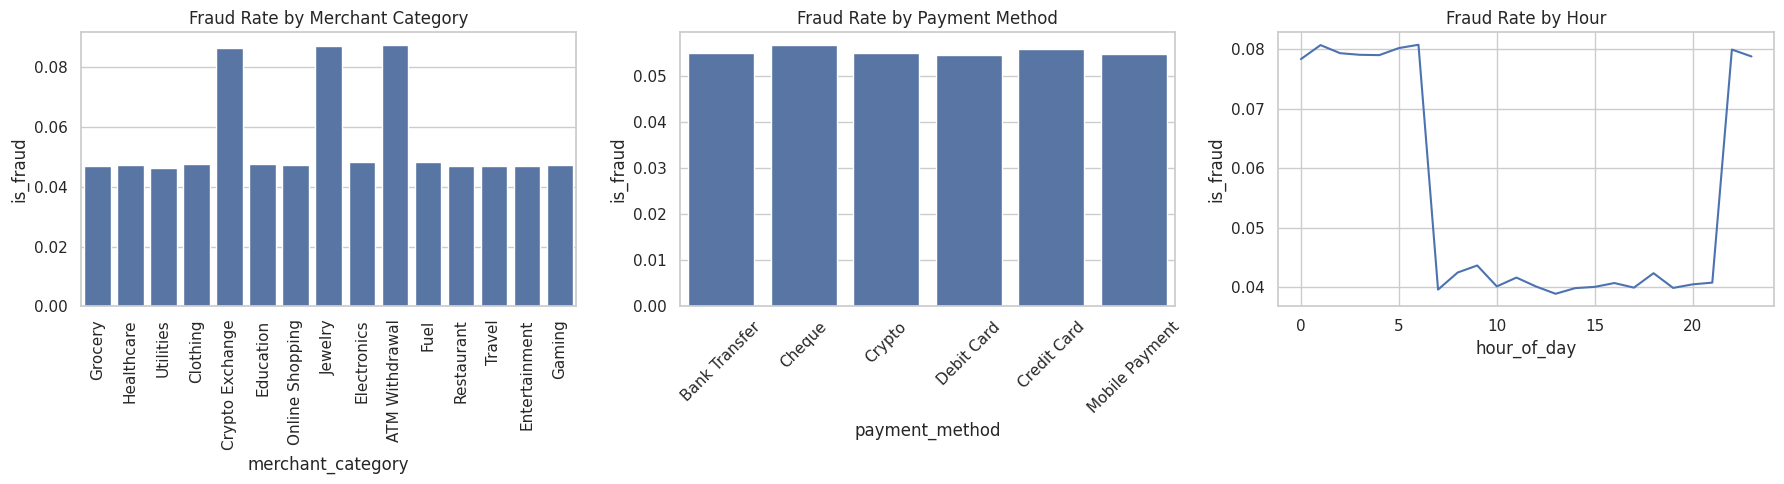

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_clean, x="merchant_category", y="is_fraud", ax=axes[0], errorbar=None)
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_title("Fraud Rate by Merchant Category")

sns.barplot(data=df_clean, x="payment_method", y="is_fraud", ax=axes[1], errorbar=None)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Fraud Rate by Payment Method")

sns.lineplot(data=df_clean.groupby("hour_of_day", as_index=False)["is_fraud"].mean(), x="hour_of_day", y="is_fraud", ax=axes[2])
axes[2].set_title("Fraud Rate by Hour")

plt.tight_layout()
plt.show()

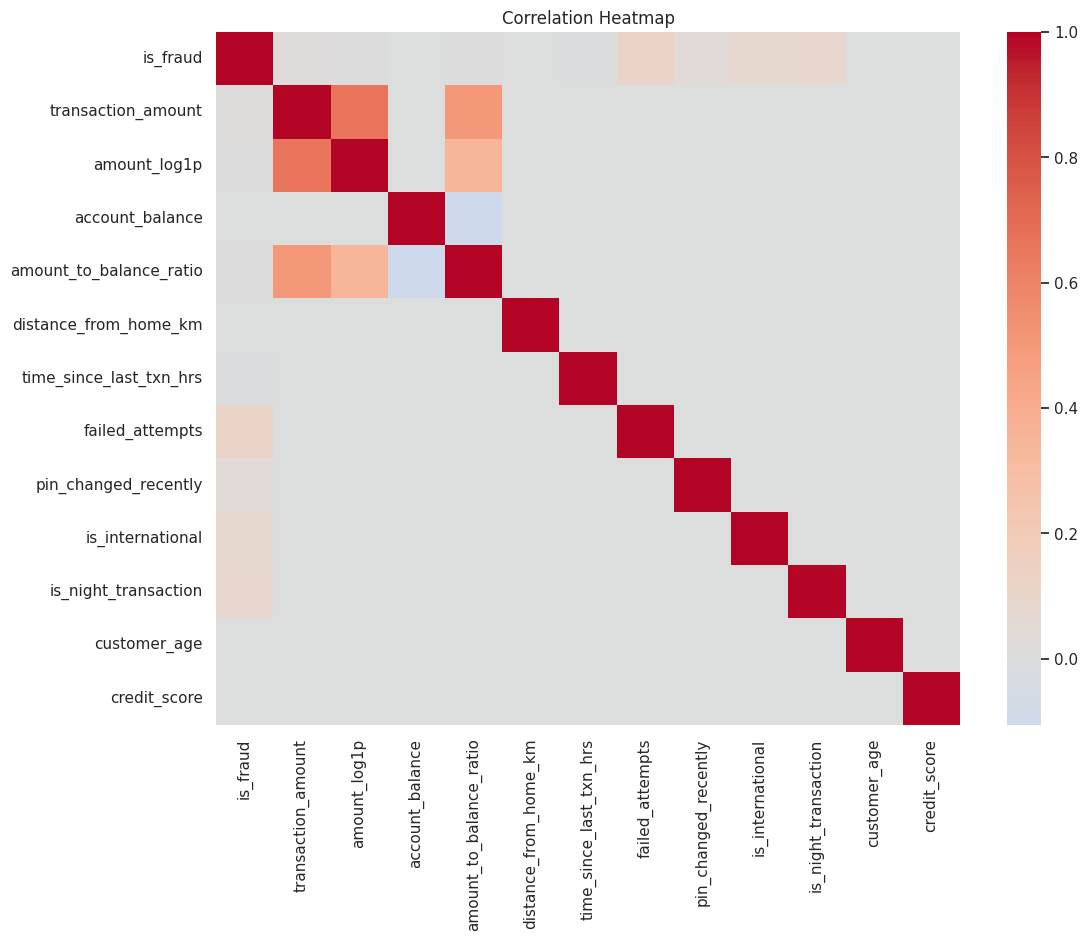

In [11]:
corr_cols = [
    "is_fraud",
    "transaction_amount",
    "amount_log1p",
    "account_balance",
    "amount_to_balance_ratio",
    "distance_from_home_km",
    "time_since_last_txn_hrs",
    "failed_attempts",
    "pin_changed_recently",
    "is_international",
    "is_night_transaction",
    "customer_age",
    "credit_score",
]

plt.figure(figsize=(12, 9))
sns.heatmap(df_clean[corr_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
TARGET = "is_fraud"
LEAKAGE_OR_ID_COLUMNS = [
    "transaction_id",
    "customer_id",
    "fraud_type",
    "transaction_date",
    "transaction_time",
    "transaction_datetime",
]

feature_df = df_clean.drop(columns=[TARGET] + LEAKAGE_OR_ID_COLUMNS)
target = df_clean[TARGET]

categorical_features = feature_df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = feature_df.select_dtypes(include=["number", "bool"]).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(categorical_features)

Numeric features: 28
Categorical features: 5
['country', 'city', 'merchant_category', 'payment_method', 'device_type']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    feature_df,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target,
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).rename("train_target_rate"))
print(y_test.value_counts(normalize=True).rename("test_target_rate"))

(800000, 33) (200000, 33)
is_fraud
0    0.944745
1    0.055255
Name: train_target_rate, dtype: float64
is_fraud
0    0.944745
1    0.055255
Name: test_target_rate, dtype: float64


In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    ),
}

trained_models = {}
metrics = []

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    trained_models[name] = pipeline
    metrics.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_proba),
            "avg_precision": average_precision_score(y_test, y_proba),
        }
    )

In [ ]:
metrics_df = pd.DataFrame(metrics).sort_values("avg_precision", ascending=False)
metrics_df

In [ ]:
best_model_name = metrics_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Best model: {best_model_name}")
print(classification_report(y_test, y_pred, target_names=["not_fraud", "fraud"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["not_fraud", "fraud"]).plot(values_format=",d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title(f"ROC Curve - {best_model_name}")

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"Precision-Recall Curve - {best_model_name}")

plt.tight_layout()
plt.show()

In [ ]:
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_metrics = []

for threshold in thresholds:
    threshold_pred = (y_proba >= threshold).astype(int)
    threshold_metrics.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_test, threshold_pred, zero_division=0),
            "recall": recall_score(y_test, threshold_pred, zero_division=0),
            "f1": f1_score(y_test, threshold_pred, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_metrics)
threshold_df.sort_values("f1", ascending=False).head(10)

In [ ]:
def get_feature_names(pipeline: Pipeline) -> np.ndarray:
    transformer = pipeline.named_steps["preprocessor"]
    return transformer.get_feature_names_out()


feature_names = get_feature_names(best_model)
model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importance = model_step.feature_importances_
elif hasattr(model_step, "coef_"):
    importance = np.abs(model_step.coef_[0])
else:
    importance = np.zeros(len(feature_names))

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importance})
    .sort_values("importance", ascending=False)
    .head(25)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, y="feature", x="importance")
plt.title(f"Top Features - {best_model_name}")
plt.tight_layout()
plt.show()

importance_df